In [1]:
import pandas as pd
df=pd.read_excel('/content/drive/MyDrive/Dataset/offres_emploi_senegal_propre (5).xlsx')

In [2]:
df.head()

,Entreprise,Ville,Type de contrat,Date de publication,Compétences,Catégories compétences,Source,Lien
0,Inconnu,Dakar,Consultant,22/04/2026,Java,Développement & Tech,senjob.com,https://senjob.com/sn/jobseekers/dev-full-stac...
1,Inconnu,Dakar,Stage,17/04/2026,Comptabilité,Finance & Comptabilité,senjob.com,https://senjob.com/sn/jobseekers/chauffeurs-de...
2,Inconnu,Dakar,CDI,22/04/2026,JavaScript,Développement & Tech,senjob.com,https://senjob.com/sn/jobseekers/dev-front-end...
3,Inconnu,Dakar,CDI,30/04/2026,Java,Développement & Tech,senjob.com,https://senjob.com/sn/jobseekers/développeur-f...
4,AMD Corporate,Dakar,CDI,01/05/2026,Java,Développement & Tech,senjob.com,https://senjob.com/sn/jobseekers/agents-de-cli...


In [3]:
df['Catégories compétences']

,Catégories compétences
0,Développement & Tech
1,Finance & Comptabilité
2,Développement & Tech
3,Développement & Tech
4,Développement & Tech
...,...
4383,Finance & Comptabilité
4384,Data & IA
4385,Finance & Comptabilité
4386,Finance & Comptabilité


In [4]:
import pandas as pd
import re

FILE = "/content/drive/MyDrive/Dataset/offres_emploi_senegal_propre (5).xlsx"

df_raw = pd.read_excel(FILE)
print(f"Lignes chargées : {len(df_raw):,}")

df = df_raw.copy()
df.columns = df.columns.str.strip()

# Doublons
avant = len(df)
df.drop_duplicates(subset=["Lien"], inplace=True)
print(f"Doublons supprimés : {avant - len(df)}")

# Valeurs manquantes
df["Compétences"] = df["Compétences"].fillna("")
df["Catégories compétences"] = df["Catégories compétences"].fillna("")
df["Entreprise"] = df["Entreprise"].fillna("Inconnu")
df["Ville"] = df["Ville"].fillna("Non renseignée")

# Extraction du titre depuis l'URL
def extraire_metier(lien):
    if not isinstance(lien, str):
        return "Non renseigné"
    match = re.search(r"/jobseekers/(.+?)_e_\d+", lien)
    if match:
        slug = match.group(1)
        slug = re.sub(r"[_­-]+", " ", slug)
        slug = re.sub(r"%[0-9a-fA-F]{2}", "", slug)
        return re.sub(r"\s+", " ", slug).strip().title()
    return "Non renseigné"

df["Titre"] = df["Lien"].apply(extraire_metier)

# Extraction des compétences en listes
def split_competences(val):
    if not isinstance(val, str) or val.strip() == "":
        return []
    return [c.strip() for c in val.split(",") if c.strip()]

df["liste_competences"] = df["Compétences"].apply(split_competences)
df["liste_categories"]  = df["Catégories compétences"].apply(split_competences)

# Standardisation des contrats
contrat_map = {
    "cdi": "CDI", "cdd": "CDD", "stage": "Stage",
    "freelance": "Freelance", "consultant": "Consultant",
    "intérim": "Intérim", "interim": "Intérim", "autre": "Autre",
}

def normaliser_contrat(val):
    if not isinstance(val, str):
        return "Autre"
    return contrat_map.get(val.strip().lower(), val.strip())

df["Contrat"] = df["Type de contrat"].apply(normaliser_contrat)

# Parsing des dates
df["Date"]    = pd.to_datetime(df["Date de publication"], dayfirst=True, errors="coerce")
df["Mois"]    = df["Date"].dt.to_period("M")
df["Année"]   = df["Date"].dt.year
df["Mois_num"]= df["Date"].dt.month

print(f"Lignes après nettoyage : {len(df):,}")
print("Colonnes créées : Titre, Contrat, Date, Mois, liste_competences")

Lignes chargées : 4,388
Doublons supprimés : 0
Lignes après nettoyage : 4,388
Colonnes créées : Titre, Contrat, Date, Mois, liste_competences


/tmp/ipykernel_9719/645212008.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(top_comp.index, rotation=40, ha="right", fontsize=8)
/tmp/ipykernel_9719/645212008.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(contrats.index, rotation=30, ha="right")
/tmp/ipykernel_9719/645212008.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(evo["Mois_str"], rotation=45, ha="right", fontsize=8)


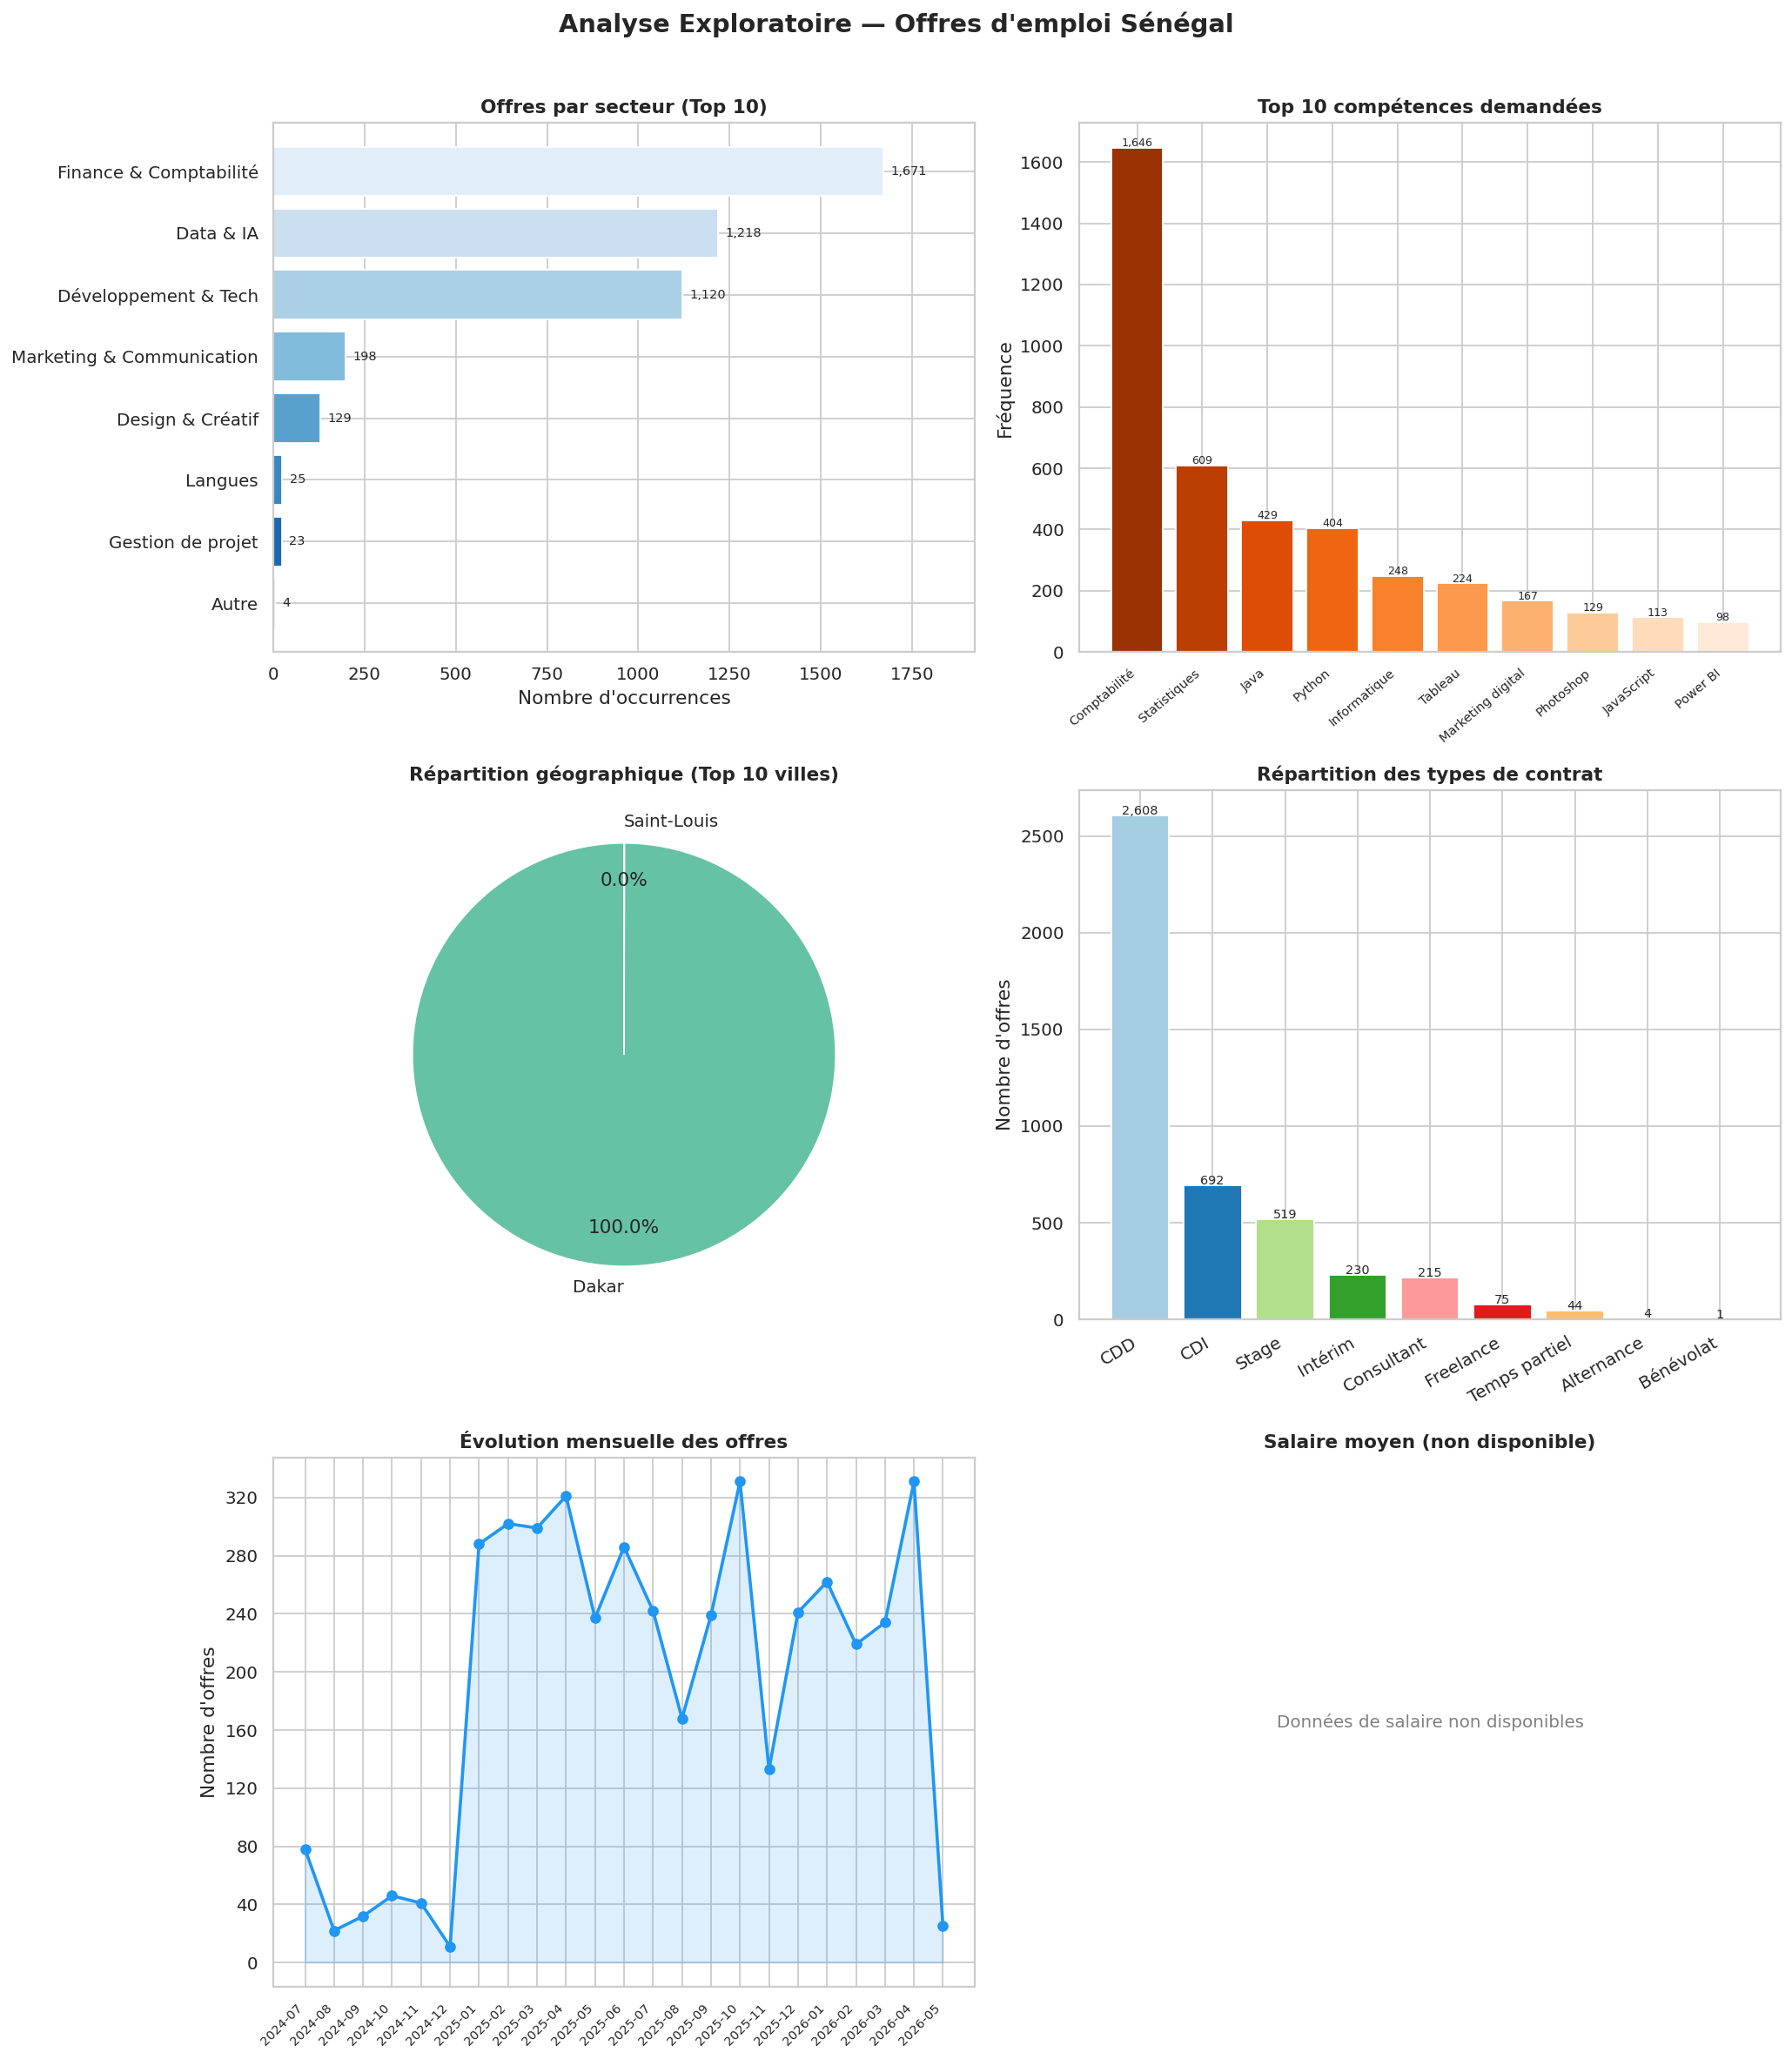

Graphiques sauvegardés → eda_offres_emploi.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130})

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Analyse Exploratoire — Offres d'emploi Sénégal", fontsize=16, fontweight="bold", y=1.01)

# 2.1 Offres par secteur
toutes_cats = [c for lst in df["liste_categories"] for c in lst]
secteurs = pd.Series(Counter(toutes_cats)).sort_values(ascending=False).head(10)

ax1 = axes[0, 0]
bars = ax1.barh(secteurs.index[::-1], secteurs.values[::-1], color=sns.color_palette("Blues_r", len(secteurs)))
ax1.set_title("Offres par secteur (Top 10)", fontweight="bold")
ax1.set_xlabel("Nombre d'occurrences")
for bar in bars:
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f"{int(bar.get_width()):,}", va="center", fontsize=8)
ax1.margins(x=0.15)

# 2.2 Top 10 compétences
toutes_comp = [c for lst in df["liste_competences"] for c in lst if c]
top_comp = pd.Series(Counter(toutes_comp)).sort_values(ascending=False).head(10)

ax2 = axes[0, 1]
ax2.bar(top_comp.index, top_comp.values, color=sns.color_palette("Oranges_r", len(top_comp)))
ax2.set_title("Top 10 compétences demandées", fontweight="bold")
ax2.set_ylabel("Fréquence")
ax2.set_xticklabels(top_comp.index, rotation=40, ha="right", fontsize=8)
for i, v in enumerate(top_comp.values):
    ax2.text(i, v + 5, f"{v:,}", ha="center", fontsize=7)

# 2.3 Répartition géographique
villes = df["Ville"].value_counts().head(10)

ax3 = axes[1, 0]
ax3.pie(villes.values, labels=villes.index, autopct="%1.1f%%",
        startangle=90, pctdistance=0.82,
        colors=sns.color_palette("Set2", len(villes)))
ax3.set_title("Répartition géographique (Top 10 villes)", fontweight="bold")

# 2.4 Types de contrat
contrats = df["Contrat"].value_counts()

ax4 = axes[1, 1]
ax4.bar(contrats.index, contrats.values, color=sns.color_palette("Paired", len(contrats)))
ax4.set_title("Répartition des types de contrat", fontweight="bold")
ax4.set_ylabel("Nombre d'offres")
ax4.set_xticklabels(contrats.index, rotation=30, ha="right")
for i, v in enumerate(contrats.values):
    ax4.text(i, v + 5, f"{v:,}", ha="center", fontsize=8)

# 2.5 Évolution mensuelle
evo = df.groupby("Mois").size().reset_index(name="nb_offres")
evo["Mois_str"] = evo["Mois"].astype(str)

ax5 = axes[2, 0]
ax5.plot(evo["Mois_str"], evo["nb_offres"], marker="o", color="#2196F3", linewidth=2, markersize=6)
ax5.fill_between(evo["Mois_str"], evo["nb_offres"], alpha=0.15, color="#2196F3")
ax5.set_title("Évolution mensuelle des offres", fontweight="bold")
ax5.set_ylabel("Nombre d'offres")
ax5.set_xticklabels(evo["Mois_str"], rotation=45, ha="right", fontsize=8)
ax5.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# 2.6 Salaire moyen
ax6 = axes[2, 1]
if "Salaire" in df.columns and df["Salaire"].notna().any():
    sal = df.dropna(subset=["Salaire"]).groupby("Contrat")["Salaire"].mean().sort_values()
    ax6.barh(sal.index, sal.values, color=sns.color_palette("Greens_r", len(sal)))
    ax6.set_title("Salaire moyen par contrat", fontweight="bold")
    ax6.set_xlabel("Salaire moyen (FCFA)")
else:
    ax6.text(0.5, 0.5, "Données de salaire non disponibles",
             ha="center", va="center", fontsize=11, color="gray", transform=ax6.transAxes)
    ax6.set_title("Salaire moyen (non disponible)", fontweight="bold")
    ax6.axis("off")

plt.tight_layout()
plt.savefig("eda_offres_emploi.png", bbox_inches="tight")
plt.show()
print("Graphiques sauvegardés → eda_offres_emploi.png")

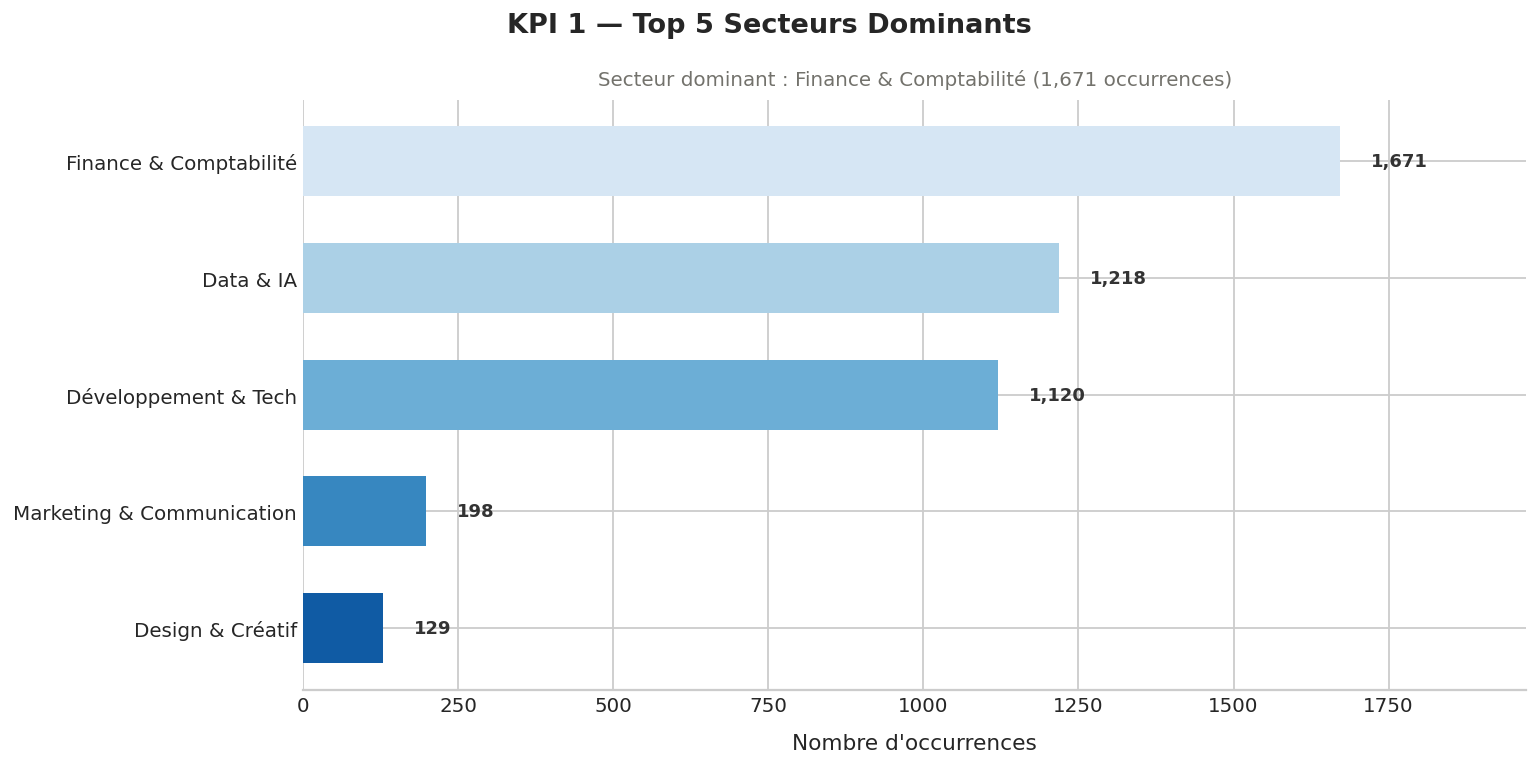

🏆 Secteur dominant : Finance & Comptabilité — 1,671 occurrences


In [6]:
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

toutes_cats = [c for lst in df["liste_categories"] for c in lst]
top5_secteurs = pd.Series(Counter(toutes_cats)).sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('KPI 1 — Top 5 Secteurs Dominants', fontsize=15, fontweight='bold')

colors = sns.color_palette("Blues_r", 5)
bars = ax.barh(top5_secteurs.index[::-1], top5_secteurs.values[::-1],
               color=colors, edgecolor='none', height=0.6)

for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", fontsize=10, fontweight='bold', color='#333')

ax.set_xlabel("Nombre d'occurrences", labelpad=10)
ax.set_title(f'Secteur dominant : {top5_secteurs.index[0]} ({top5_secteurs.values[0]:,} occurrences)',
             fontsize=11, color='#73726c', pad=8)
ax.tick_params(length=0)
ax.margins(x=0.18)
ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig('kpi_1_secteurs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"🏆 Secteur dominant : {top5_secteurs.index[0]} — {top5_secteurs.values[0]:,} occurrences")

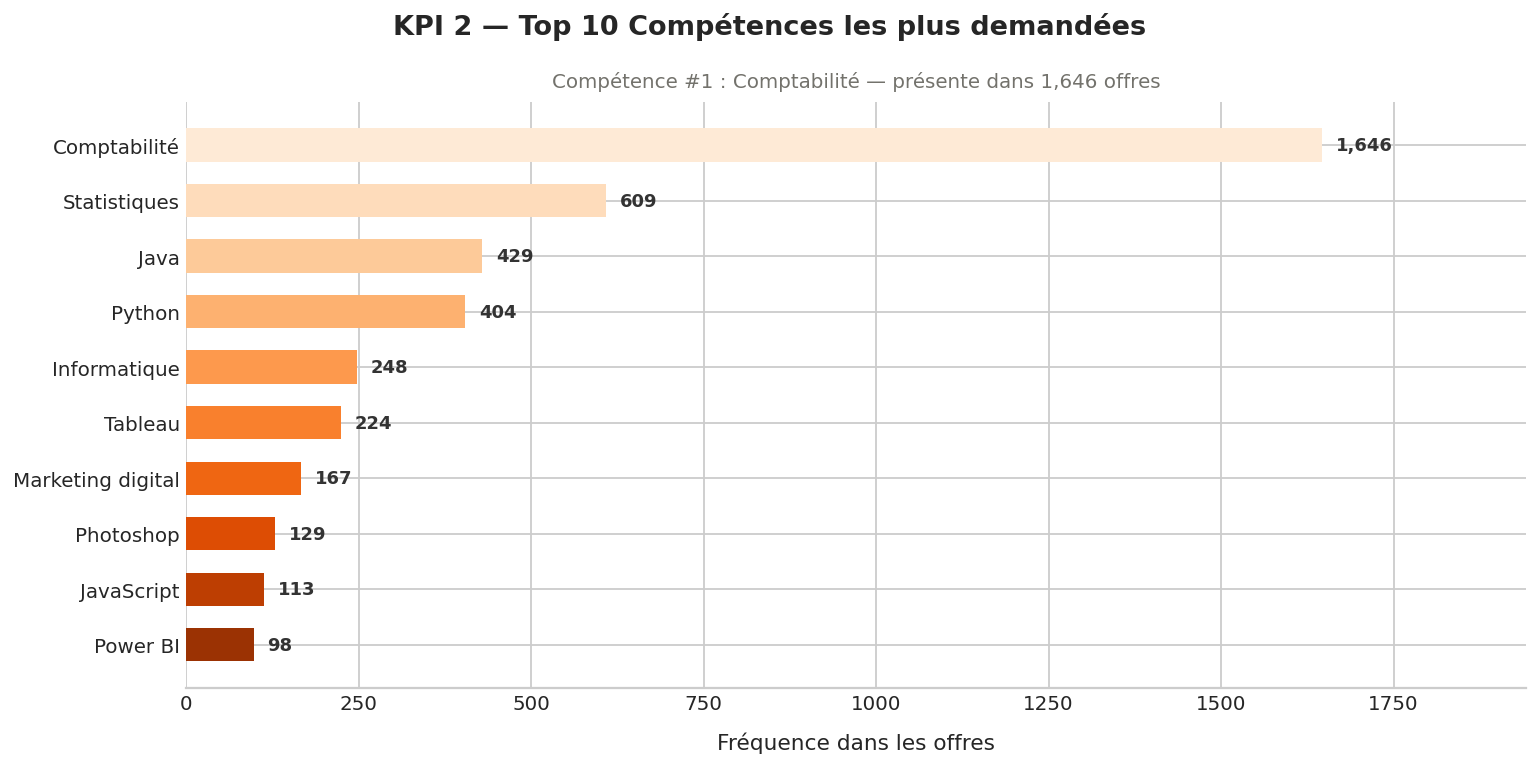

🔑 Compétence #1 : Comptabilité — 1,646 offres


In [7]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

toutes_comp = [c for lst in df["liste_competences"] for c in lst if c]
top10_comp = pd.Series(Counter(toutes_comp)).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('KPI 2 — Top 10 Compétences les plus demandées', fontsize=15, fontweight='bold')

colors = sns.color_palette("Oranges_r", 10)
bars = ax.barh(top10_comp.index[::-1], top10_comp.values[::-1],
               color=colors, edgecolor='none', height=0.6)

for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", fontsize=10, fontweight='bold', color='#333')

ax.set_xlabel("Fréquence dans les offres", labelpad=10)
ax.set_title(f'Compétence #1 : {top10_comp.index[0]} — présente dans {top10_comp.values[0]:,} offres',
             fontsize=11, color='#73726c', pad=8)
ax.tick_params(length=0)
ax.margins(x=0.18)
ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig('kpi_2_competences.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"🔑 Compétence #1 : {top10_comp.index[0]} — {top10_comp.values[0]:,} offres")

/tmp/ipykernel_9719/953013599.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(villes.index, rotation=35, ha='right', fontsize=10)
/tmp/ipykernel_9719/953013599.py:54: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.savefig('kpi_3_geographie.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


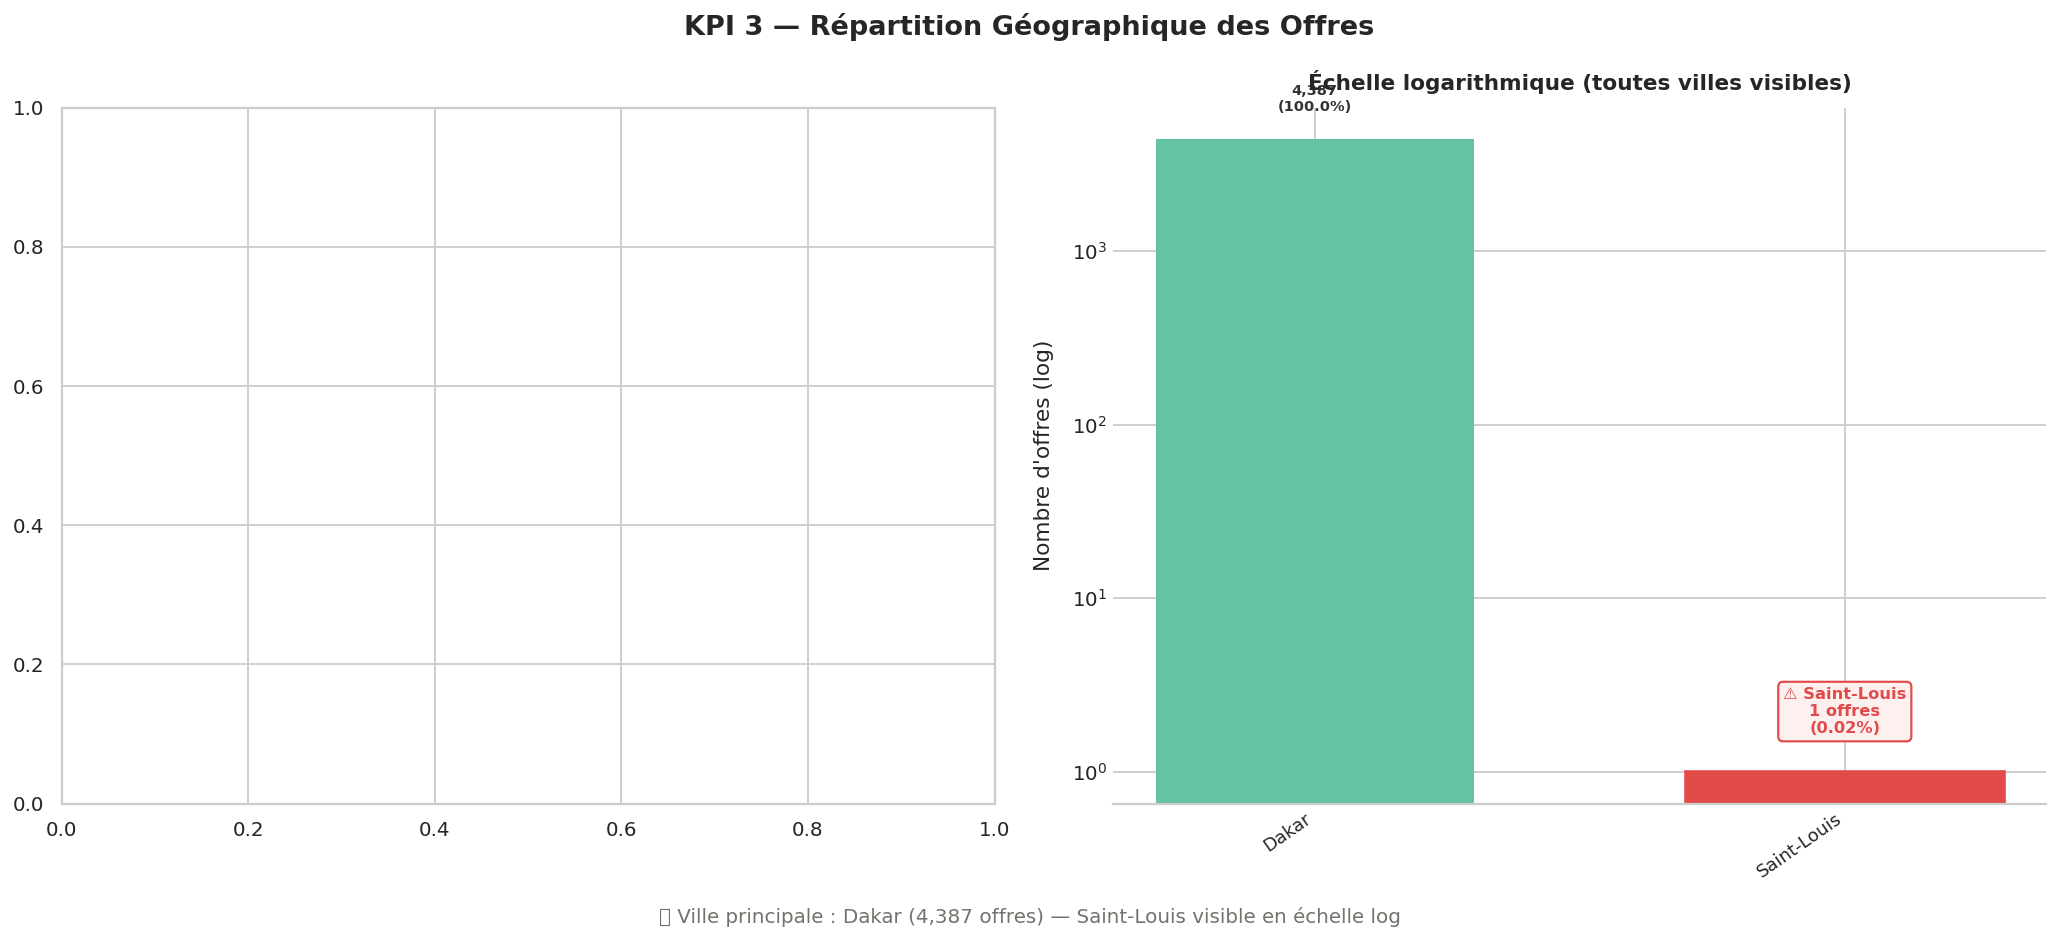

📍 Ville principale : Dakar — 4,387 offres
📍 Saint-Louis : 1 offres


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

villes = df["Ville"].value_counts().head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('KPI 3 — Répartition Géographique des Offres', fontsize=15, fontweight='bold')

colors = sns.color_palette("Set2", len(villes))



# ── Graphique 2 : Échelle logarithmique ───────────────────
bars2 = ax2.bar(villes.index, villes.values,
                color=colors, edgecolor='none', width=0.6)

ax2.set_yscale('log')

for bar, (ville, val) in zip(bars2, villes.items()):
    pct = val / len(df) * 100
    # Surligner Saint-Louis en rouge
    if 'Saint' in ville or 'saint' in ville:
        bar.set_color('#E24B4A')
        bar.set_linewidth(2)
        ax2.text(bar.get_x() + bar.get_width()/2,
                 val * 1.6,
                 f"⚠ {ville}\n{val:,} offres\n({pct:.2f}%)",
                 ha="center", va="bottom", fontsize=9,
                 fontweight='bold', color='#E24B4A',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF0F0',
                           edgecolor='#E24B4A', linewidth=1.2))
    else:
        ax2.text(bar.get_x() + bar.get_width()/2,
                 val * 1.4,
                 f"{val:,}\n({pct:.1f}%)",
                 ha="center", va="bottom", fontsize=8,
                 fontweight='bold', color='#333')

ax2.set_title('Échelle logarithmique (toutes villes visibles)', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel("Nombre d'offres (log)", labelpad=10)
ax2.set_xticklabels(villes.index, rotation=35, ha='right', fontsize=10)
ax2.tick_params(length=0)
ax2.spines[['top', 'right', 'left']].set_visible(False)

ville_top = villes.index[0]
nb_top    = villes.values[0]
fig.text(0.5, -0.02,
         f"📍 Ville principale : {ville_top} ({nb_top:,} offres) — Saint-Louis visible en échelle log",
         ha='center', fontsize=11, color='#73726c')

plt.tight_layout()
plt.savefig('kpi_3_geographie.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📍 Ville principale : {ville_top} — {nb_top:,} offres")
print(f"📍 Saint-Louis : {villes.get('Saint-Louis', 0):,} offres")

── Métriques globales ──
  Moyenne mensuelle  : 198 offres/mois
  Mois pic           : 2025-10 (331 offres)
  Dernier mois       : Apr 26 (331 offres)
  Croissance last    : +41.5%
  Croissance 2024→25 : +1242.2%


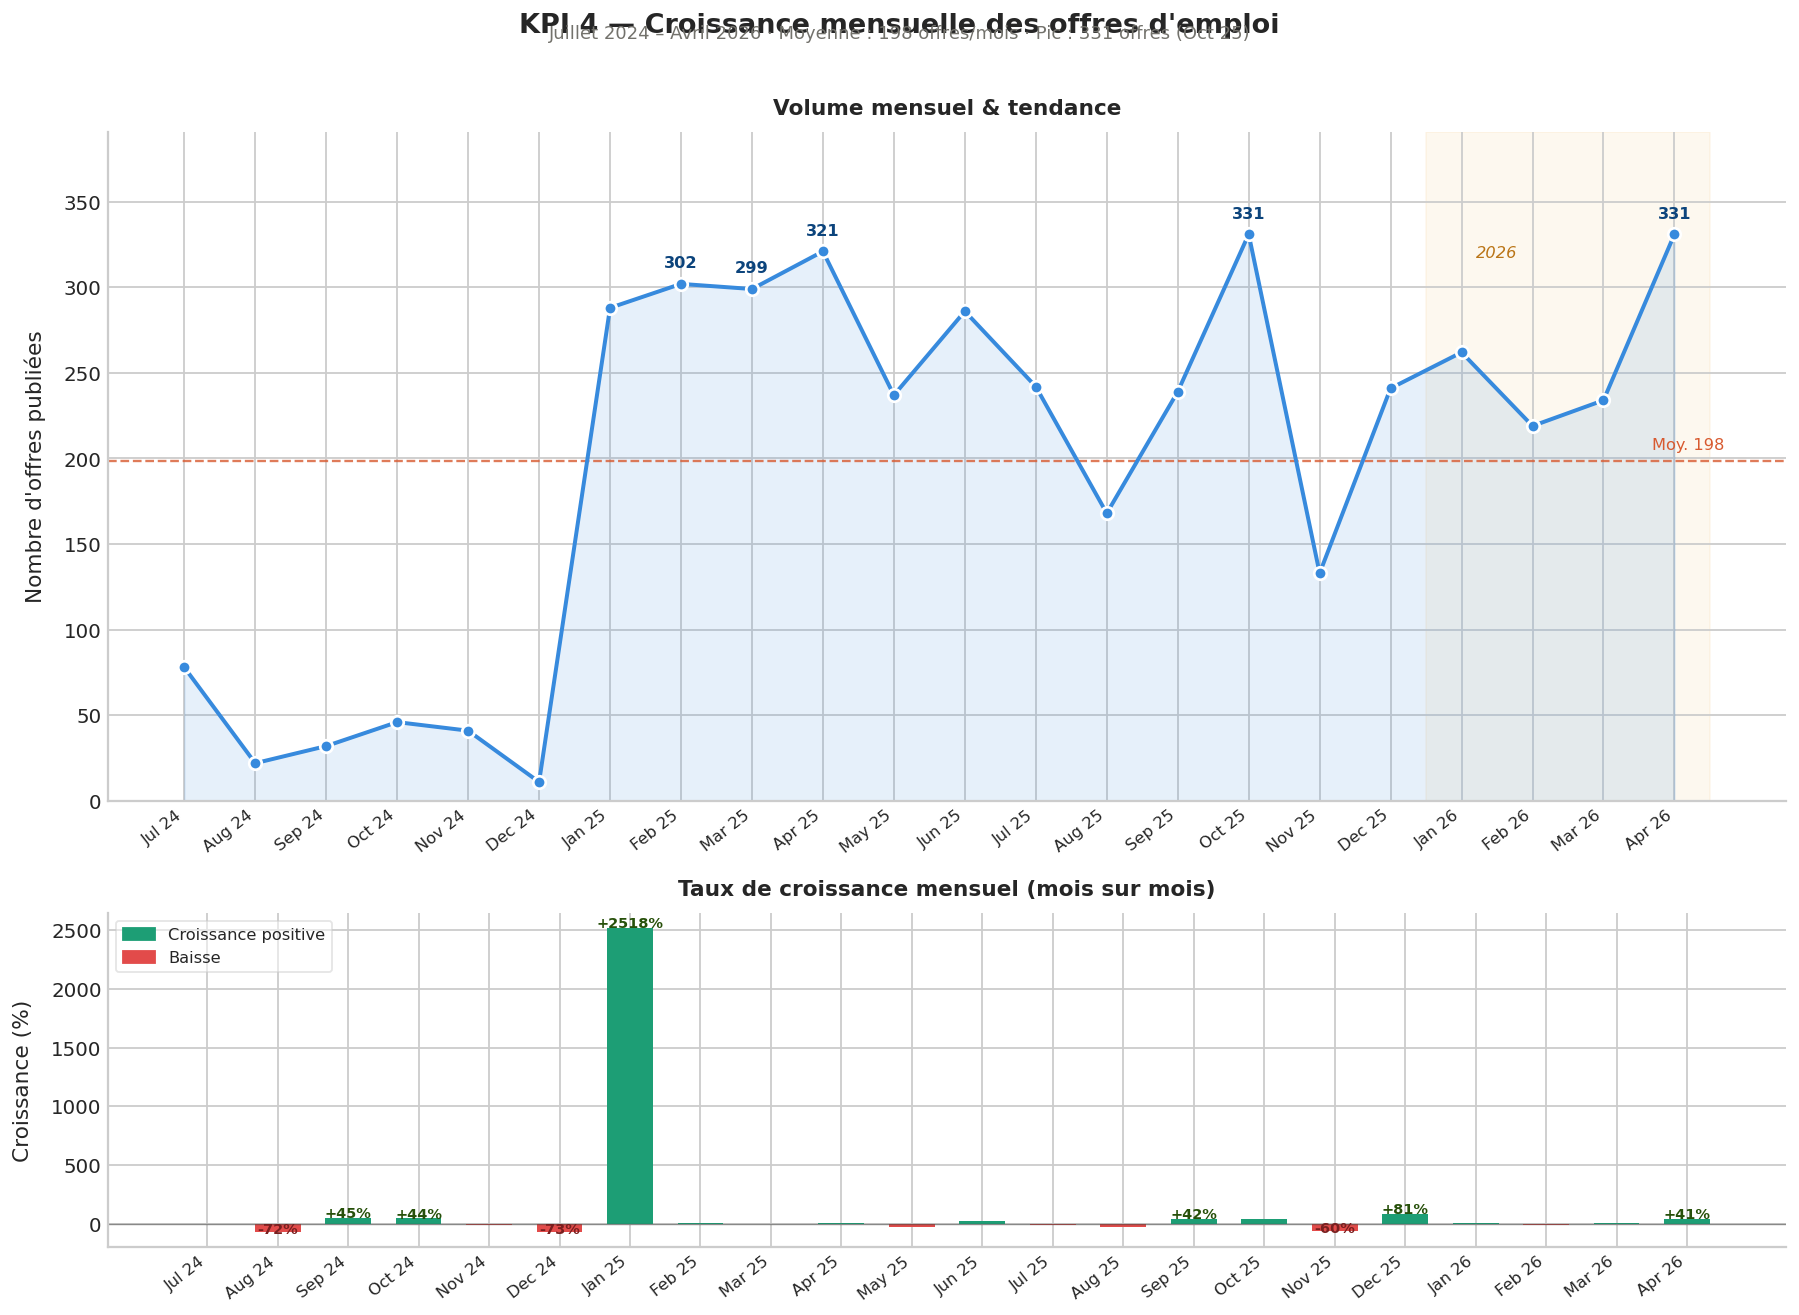


🏆 Pic : 331 offres en Oct 25
   Croissance dernier mois : +41.5%
   Croissance 2024 → 2025  : +1242.2%


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Préparation des données
df['annee_mois'] = df['Date'].dt.to_period('M')

evol = (
    df.groupby('annee_mois')
      .size()
      .reset_index(name='n')
)
# Exclure mai 2026 (mois incomplet)
evol = evol[evol['annee_mois'] < pd.Period('2026-05', 'M')].reset_index(drop=True)
evol['label']      = evol['annee_mois'].dt.strftime('%b %y')
evol['croissance'] = evol['n'].pct_change() * 100

# Métriques globales
moy_mensuelle  = evol['n'].mean()
mois_pic       = evol.loc[evol['n'].idxmax()]
crois_last     = evol['croissance'].iloc[-1]
n2024 = evol[evol['annee_mois'].dt.year == 2024]['n'].sum()
n2025 = evol[evol['annee_mois'].dt.year == 2025]['n'].sum()
crois_annuelle = (n2025 - n2024) / n2024 * 100 if n2024 > 0 else 0

print('── Métriques globales ──')
print(f'  Moyenne mensuelle  : {moy_mensuelle:.0f} offres/mois')
print(f'  Mois pic           : {mois_pic["annee_mois"]} ({mois_pic["n"]} offres)')
print(f'  Dernier mois       : {evol.iloc[-1]["label"]} ({evol.iloc[-1]["n"]} offres)')
print(f'  Croissance last    : {crois_last:+.1f}%')
print(f'  Croissance 2024→25 : {crois_annuelle:+.1f}%')

# ── Figure 2 sous-graphiques ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle("KPI 4 — Croissance mensuelle des offres d'emploi",
             fontsize=15, fontweight='bold', y=1.01)
fig.text(0.5, 0.99,
         f"Juillet 2024 – Avril 2026 · Moyenne : {moy_mensuelle:.0f} offres/mois · Pic : {int(mois_pic['n'])} offres ({mois_pic['label']})",
         ha='center', fontsize=10, color='#73726c')

x = range(len(evol))
y = evol['n'].values

# Graphique 1 : Courbe + Aire
ax1.fill_between(x, y, alpha=0.12, color='#378ADD')
ax1.plot(x, y, color='#378ADD', linewidth=2.2, zorder=3)
ax1.scatter(x, y, color='#378ADD', s=48, zorder=4, edgecolor='white', linewidth=1.5)

for xi, yi in zip(x, y):
    if yi >= 290:
        ax1.annotate(f'{yi}', xy=(xi, yi), xytext=(0, 9),
                     textcoords='offset points', ha='center',
                     fontsize=9, fontweight='bold', color='#0C447C')

ax1.axhline(moy_mensuelle, color='#D85A30', linewidth=1.3, linestyle='--', alpha=0.8)
ax1.text(len(x) - 0.3, moy_mensuelle + 7,
         f'Moy. {moy_mensuelle:.0f}', color='#D85A30', fontsize=9, ha='right')

idx_2026 = evol[evol['annee_mois'].dt.year == 2026].index
if len(idx_2026):
    d26 = evol.index.get_loc(idx_2026[0])
    ax1.axvspan(d26 - 0.5, len(x) - 0.5, color='#EF9F27', alpha=0.07, zorder=0)
    ax1.text(d26 + 0.2, max(y) * 0.96, '2026', fontsize=9, color='#BA7517', style='italic')

ax1.set_ylabel("Nombre d'offres publiées", labelpad=10)
ax1.set_ylim(0, max(y) * 1.18)
ax1.set_xticks(list(x))
ax1.set_xticklabels(evol['label'], rotation=38, ha='right', fontsize=9)
ax1.tick_params(length=0)
ax1.set_title('Volume mensuel & tendance', fontsize=12, fontweight='bold', pad=10)
ax1.spines[['top','right']].set_visible(False)

# Graphique 2 : Taux de croissance
crois  = evol['croissance'].fillna(0).values
colors_bar = ['#1D9E75' if c >= 0 else '#E24B4A' for c in crois]

ax2.bar(range(len(evol)), crois, color=colors_bar, width=0.65, edgecolor='none')
ax2.axhline(0, color='#444441', linewidth=0.8, alpha=0.5)

for xi, ci in enumerate(crois):
    if abs(ci) >= 40:
        offset = 3 if ci >= 0 else -12
        ax2.text(xi, ci + offset, f'{ci:+.0f}%', ha='center', fontsize=8,
                 color='#27500A' if ci >= 0 else '#791F1F', fontweight='bold')

ax2.set_ylabel('Croissance (%)', labelpad=10)
ax2.set_xticks(range(len(evol)))
ax2.set_xticklabels(evol['label'], rotation=38, ha='right', fontsize=9)
ax2.tick_params(length=0)
ax2.set_title('Taux de croissance mensuel (mois sur mois)', fontsize=12, fontweight='bold', pad=10)
ax2.spines[['top','right']].set_visible(False)

legend_patches = [
    mpatches.Patch(color='#1D9E75', label='Croissance positive'),
    mpatches.Patch(color='#E24B4A', label='Baisse')
]
ax2.legend(handles=legend_patches, fontsize=9, loc='upper left', framealpha=0.5)

fig.tight_layout()
plt.savefig('kpi_4_croissance_mensuelle.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🏆 Pic : {int(mois_pic["n"])} offres en {mois_pic["label"]}')
print(f'   Croissance dernier mois : {crois_last:+.1f}%')
print(f'   Croissance 2024 → 2025  : {crois_annuelle:+.1f}%')

/tmp/ipykernel_9719/2421249908.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(contrats.index, rotation=35, ha='right', fontsize=10)


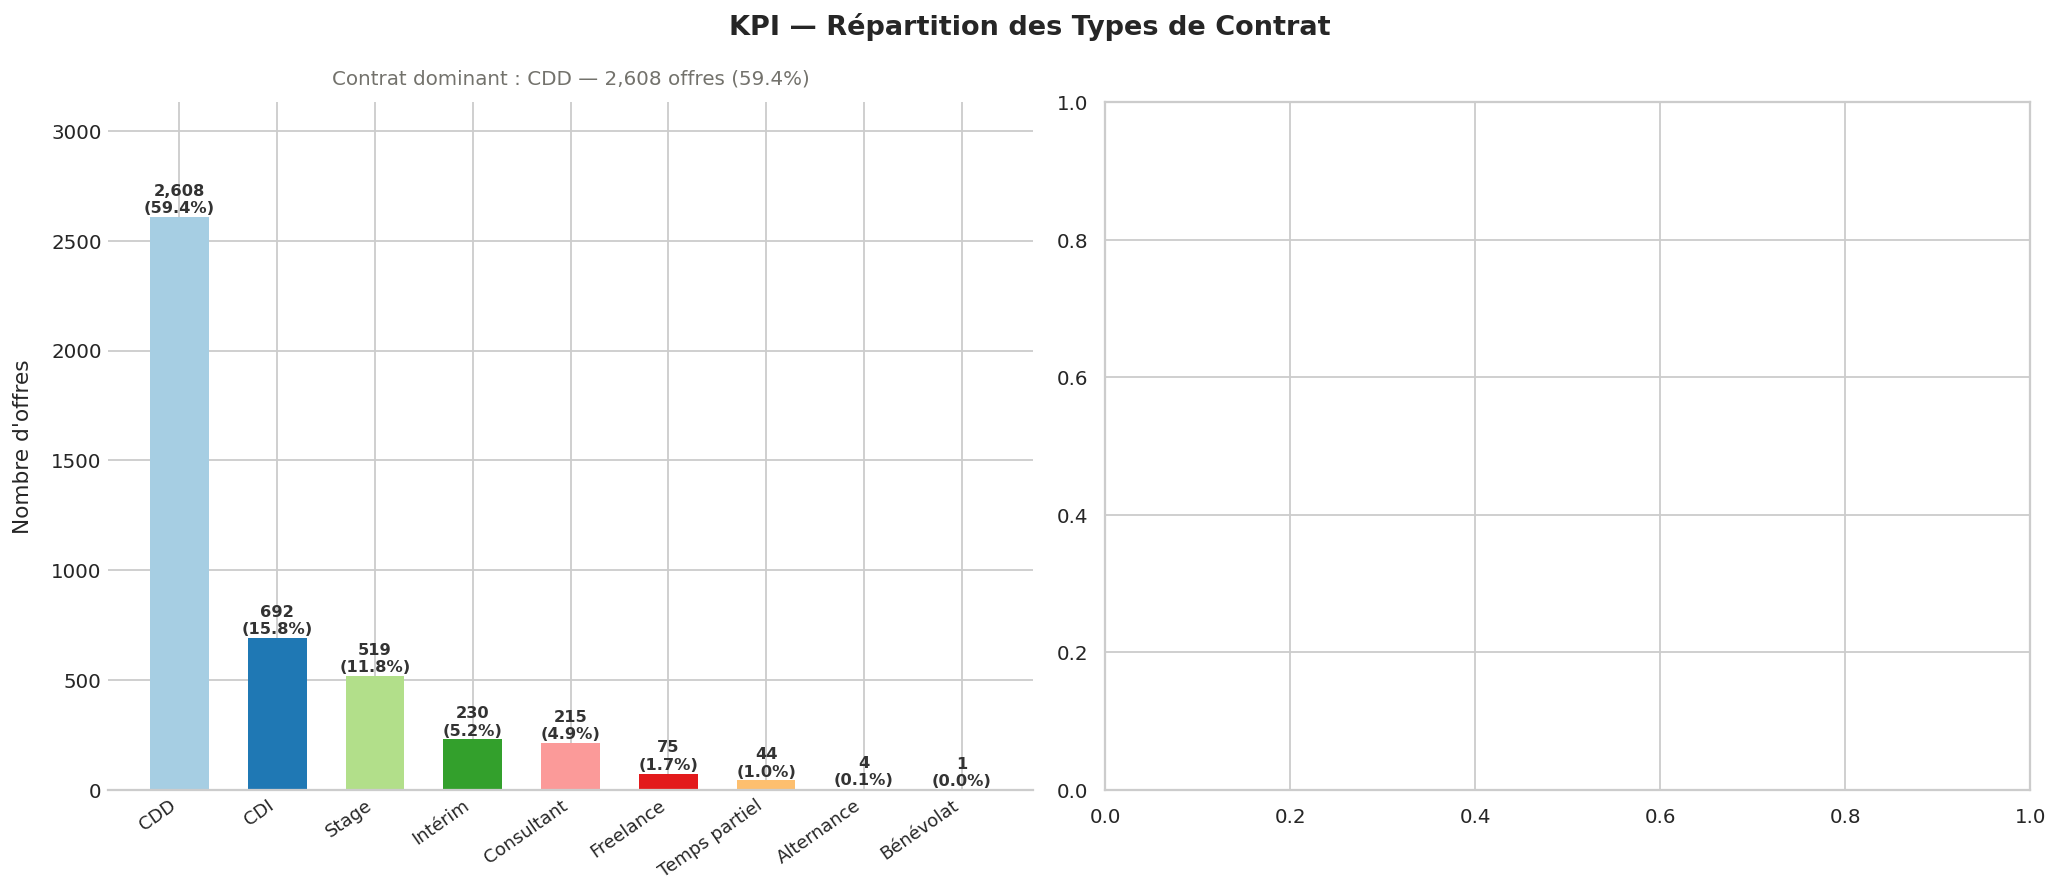


── Répartition des contrats ──
  CDD             : 2,608 offres (59.4%)
  CDI             : 692 offres (15.8%)
  Stage           : 519 offres (11.8%)
  Intérim         : 230 offres (5.2%)
  Consultant      : 215 offres (4.9%)
  Freelance       : 75 offres (1.7%)
  Temps partiel   : 44 offres (1.0%)
  Alternance      : 4 offres (0.1%)
  Bénévolat       : 1 offres (0.0%)


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

contrats = df["Contrat"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('KPI — Répartition des Types de Contrat', fontsize=15, fontweight='bold')

colors = sns.color_palette("Paired", len(contrats))

# ── Graphique 1 : Barres verticales ───────────────────────
bars = ax1.bar(contrats.index, contrats.values,
               color=colors, edgecolor='none', width=0.6)

for bar in bars:
    val = int(bar.get_height())
    pct = val / len(df) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"{val:,}\n({pct:.1f}%)",
             ha="center", va="bottom", fontsize=9, fontweight='bold', color='#333')

contrat_top = contrats.index[0]
nb_top      = contrats.values[0]

ax1.set_title(f'Contrat dominant : {contrat_top} — {nb_top:,} offres ({nb_top/len(df)*100:.1f}%)',
              fontsize=11, color='#73726c', pad=10)
ax1.set_ylabel("Nombre d'offres", labelpad=10)
ax1.set_xticklabels(contrats.index, rotation=35, ha='right', fontsize=10)
ax1.tick_params(length=0)
ax1.margins(y=0.2)
ax1.spines[['top', 'right', 'left']].set_visible(False)



# Légende
legend_patches = [mpatches.Patch(color=colors[i], label=f"{contrats.index[i]} ({contrats.values[i]:,})")
                  for i in range(len(contrats))]


plt.tight_layout()
plt.savefig('kpi_contrats.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n── Répartition des contrats ──")
for c, n in contrats.items():
    print(f"  {c:<15} : {n:,} offres ({n/len(df)*100:.1f}%)")